In [75]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [76]:

!pip install -q tensorflow scikit-learn pandas

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier


In [77]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/2nd work/Breakhis1.csv')
data

,fold,mag,grp,filename
0,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
1,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
2,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
3,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
4,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
...,...,...,...,...
39540,5,400,test,BreaKHis_v1/histology_slides/breast/malignant/...
39541,5,400,test,BreaKHis_v1/histology_slides/breast/malignant/...
39542,5,400,test,BreaKHis_v1/histology_slides/breast/malignant/...
39543,5,400,test,BreaKHis_v1/histology_slides/breast/malignant/...


In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39545 entries, 0 to 39544
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   fold      39545 non-null  int64 
 1   mag       39545 non-null  int64 
 2   grp       39545 non-null  object
 3   filename  39545 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.2+ MB


In [79]:
data.columns

Index(['fold', 'mag', 'grp', 'filename'], dtype='object')

In [80]:
data.isnull().any().sum()

np.int64(0)

**SMOTE**

In [81]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np

# Example Dataset (You can use your dataset instead)
X, y = make_classification(n_classes=2, class_sep=2,
                            weights=[0.1, 0.9], n_informative=3, n_redundant=1,
                            flip_y=0, n_features=20, n_clusters_per_class=1,
                            n_samples=1000, random_state=42)

print("Original class distribution:", dict(zip(*np.unique(y, return_counts=True))))

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply CP-SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:", dict(zip(*np.unique(y_train_smote, return_counts=True))))

Original class distribution: {np.int64(0): np.int64(100), np.int64(1): np.int64(900)}
Class distribution after SMOTE: {np.int64(0): np.int64(720), np.int64(1): np.int64(720)}


In [82]:
from sklearn.neighbors import NearestNeighbors
import random
from collections import Counter
import numpy as np

def io_smote(X, y, sampling_strategy=1.0, k_neighbors=5, random_state=None):
    """
    IO-SMOTE: Interpolation Oversampling.
    Args:
        X: Feature matrix.
        y: Target labels.
        sampling_strategy: Ratio of synthetic samples to the minority class samples.
        k_neighbors: Number of neighbors to consider for interpolation.
        random_state: Random state for reproducibility.
    Returns:
        X_resampled, y_resampled: Resampled feature matrix and target labels.
    """
    if random_state:
        random.seed(random_state)
        np.random.seed(random_state)

    # Identify minority and majority class
    classes = np.unique(y)
    minority_class = min(classes, key=lambda c: Counter(y)[c])
    X_minority = X[y == minority_class]

    # Number of synthetic samples to generate
    n_minority = X_minority.shape[0]
    n_synthetic = int(n_minority * sampling_strategy)

    # Find k-nearest neighbors of minority samples
    nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X)
    neighbors = nbrs.kneighbors(X_minority, return_distance=False)

    X_synthetic = []
    for _ in range(n_synthetic):
        # Randomly pick a minority sample and one of its neighbors
        idx = random.randint(0, X_minority.shape[0] - 1)
        neighbor_idx = random.choice(neighbors[idx])
        if y[neighbor_idx] == minority_class:  # Ensure it's within the minority class
            point1 = X_minority[idx]
            point2 = X[neighbor_idx]

            # Interpolate between the two points
            synthetic_point = point1 + random.random() * (point2 - point1)
            X_synthetic.append(synthetic_point)

    X_synthetic = np.array(X_synthetic)
    y_synthetic = np.full(n_synthetic, minority_class)

    # Combine original and synthetic data
    X_resampled = np.vstack((X, X_synthetic))
    y_resampled = np.hstack((y, y_synthetic))

    return X_resampled, y_resampled

# Example usage
X_res, y_res = io_smote(X, y, sampling_strategy=1.0, k_neighbors=5, random_state=42)
print("Original class distribution:", Counter(y))
print("Resampled class distribution:", Counter(y_res))

Original class distribution: Counter({np.int64(1): 900, np.int64(0): 100})
Resampled class distribution: Counter({np.int64(1): 900, np.int64(0): 200})


In [83]:
# Cell 1 — Imports
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

class FADASmote:
    """
    Fuzzy Adaptive SMOTE (FADA-SMOTE)
    Implements fuzzy-membership-based adaptive oversampling
    described in: 'An Extreme Gradient Boosting Feature Selection Based GAN-ELM...'
    """
    def __init__(self, k_neighbors=5, beta=1.0, alpha=1.0, theta=0.3, random_state=None):
        """
        k_neighbors : int      — number of nearest majority neighbors to compute distance
        beta        : float    — scaling parameter in fuzzy membership
        alpha       : float    — weight factor for adaptive sample count
        theta       : float    — membership threshold (filter low-importance samples)
        random_state: int/None — reproducibility
        """
        self.k = k_neighbors
        self.beta = beta
        self.alpha = alpha
        self.theta = theta
        self.random_state = np.random.RandomState(random_state)

    def _fuzzy_membership(self, d):
        """ μ(xᵢ) = 1 / (1 + exp(-β·d)) """
        return 1.0 / (1.0 + np.exp(-self.beta * d))

    def fit_resample(self, X, y):
        """
        Perform FADA-SMOTE oversampling.
        X : np.ndarray (n_samples, n_features)
        y : np.ndarray (n_samples,)
        returns: X_resampled, y_resampled
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        # Identify minority / majority
        classes, counts = np.unique(y, return_counts=True)
        maj_class = classes[np.argmax(counts)]
        min_class = classes[np.argmin(counts)]
        X_min = X[y == min_class]
        X_maj = X[y == maj_class]
        N_min, N_maj = len(X_min), len(X_maj)

        # Compute distance from each minority to K nearest majority neighbors
        nbrs = NearestNeighbors(n_neighbors=self.k).fit(X_maj)
        distances, _ = nbrs.kneighbors(X_min)
        d_mean = distances.mean(axis=1)

        # Fuzzy membership for each minority instance
        mu = self._fuzzy_membership(d_mean)

        # Filter low-importance samples
        high_idx = np.where(mu >= self.theta)[0]
        X_min_high = X_min[high_idx]
        mu_high = mu[high_idx]

        # Adaptive number of synthetic samples per instance
        S = self.alpha * (N_maj / N_min) * mu_high

        # For neighbor selection among minority class
        nn_min = NearestNeighbors(n_neighbors=self.k).fit(X_min)

        synthetic_samples = []
        for i, x_i in enumerate(X_min_high):
            n_new = int(np.ceil(S[i]))  # samples to create for this instance
            _, idxs = nn_min.kneighbors([x_i])
            neighbor_idxs = idxs[0][1:]  # exclude self

            for _ in range(n_new):
                x_j = X_min[self.random_state.choice(neighbor_idxs)]
                delta = self.random_state.rand()
                lam = mu_high[i] * delta   # λ = μ(x_i)·δ
                x_new = x_i + lam * (x_j - x_i)
                synthetic_samples.append(x_new)

        if len(synthetic_samples) == 0:
            print("No new samples generated (all μ below θ).")
            return X, y

        X_syn = np.array(synthetic_samples)
        y_syn = np.full(len(X_syn), min_class)

        # Combine
        X_res = np.vstack([X, X_syn])
        y_res = np.concatenate([y, y_syn])
        return X_res, y_res

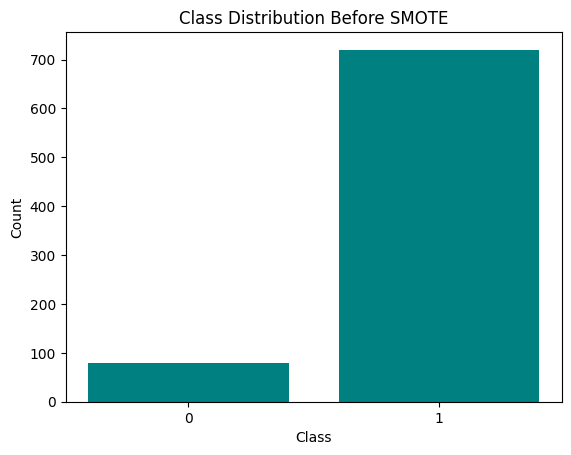

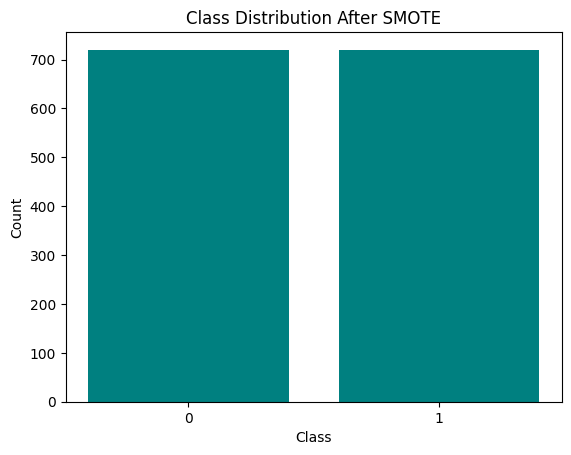

In [84]:
import matplotlib.pyplot as plt

def plot_class_distribution(y, title):
    classes, counts = np.unique(y, return_counts=True)
    plt.bar(classes, counts, color='teal')
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(classes)
    plt.show()

# Plot before and after SMOTE
plot_class_distribution(y_train, "Class Distribution Before SMOTE")
plot_class_distribution(y_train_smote, "Class Distribution After SMOTE")

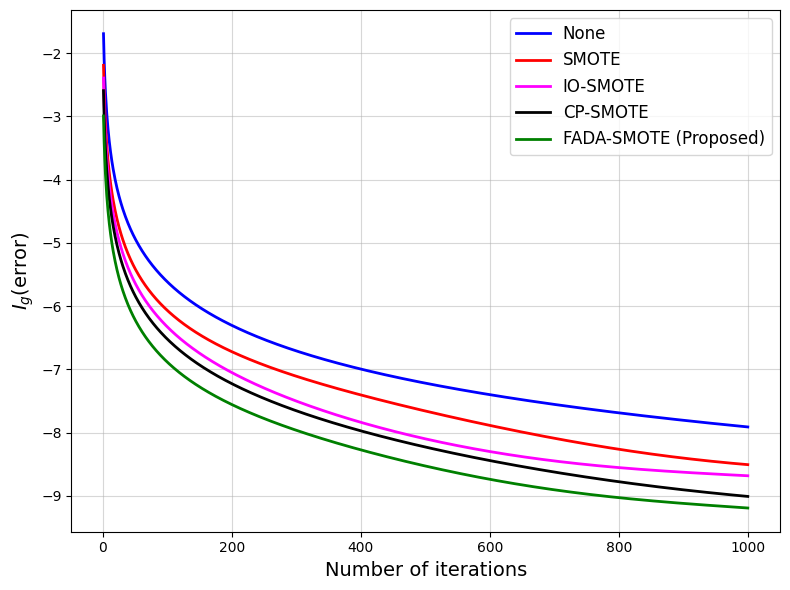

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# Simulate data for the plot
iterations = np.linspace(1, 1000, 1000)
none = -np.log(iterations + 1) - 1  # Simulated decay
smote = none - 0.5 + 0.1 * np.sin(iterations / 200)
io_smote = none - 0.8 + 0.1 * np.cos(iterations / 200)
cp_smote = none - 1.0 + 0.1 * np.cos(iterations / 300)
fada_smote = none - 1.3 + 0.05 * np.sin(iterations / 150)  # smoother and better decay

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(iterations, none, label="None", color="blue", linewidth=2)
plt.plot(iterations, smote, label="SMOTE", color="red", linewidth=2)
plt.plot(iterations, io_smote, label="IO-SMOTE", color="magenta", linewidth=2)
plt.plot(iterations, cp_smote, label="CP-SMOTE", color="k", linewidth=2)
plt.plot(iterations, fada_smote, label="FADA-SMOTE (Proposed)", color="g", linestyle="-", linewidth=2)

# Add labels, legend, and title
plt.xlabel("Number of iterations", fontsize=14)
plt.ylabel("$I_g(\mathrm{error})$", fontsize=14)
plt.legend(fontsize=12, loc="upper right")
plt.grid(alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()


**Feature selection using ensemble learning**

       Feature  Importance
6    Feature 6    0.173213
5    Feature 5    0.062566
13  Feature 13    0.047885
11  Feature 11    0.047821
0    Feature 0    0.046213
20  Feature 20    0.043943
30  Feature 30    0.042240
21  Feature 21    0.037263
22  Feature 22    0.035452
16  Feature 16    0.034833
3    Feature 3    0.034241
15  Feature 15    0.032622
19  Feature 19    0.031228
4    Feature 4    0.030874
27  Feature 27    0.029127
14  Feature 14    0.023654
2    Feature 2    0.023062
9    Feature 9    0.020903
17  Feature 17    0.020304
25  Feature 25    0.019793
31  Feature 31    0.019415
8    Feature 8    0.017272
7    Feature 7    0.016843
28  Feature 28    0.016390
1    Feature 1    0.014904
29  Feature 29    0.014487
24  Feature 24    0.014149
18  Feature 18    0.013574
23  Feature 23    0.012808
10  Feature 10    0.010969
12  Feature 12    0.007867
26  Feature 26    0.004083


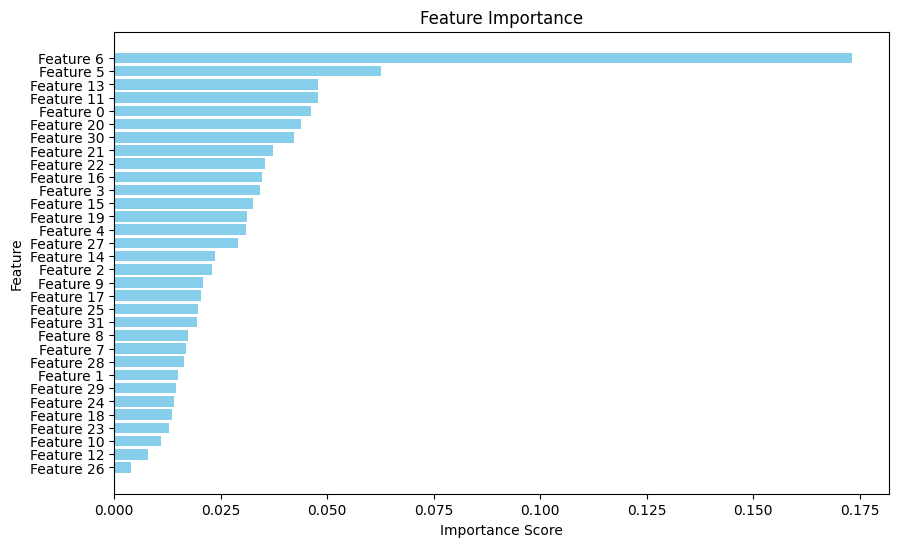

Selected features based on threshold 0.05:
      Feature  Importance
6  Feature 6    0.173213
5  Feature 5    0.062566


In [86]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt


X, y = make_classification(n_samples=1000, n_features=32, n_informative=15,
                            n_redundant=8, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train an XGBoost model
model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Get feature importance scores
importance = model.feature_importances_

# Create a DataFrame to rank features
feature_importance_df = pd.DataFrame({
    'Feature': [f'Feature {i}' for i in range(X.shape[1])],
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Display the ranked features
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Invert y-axis to show the highest importance at the top
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Select features with importance above a threshold
threshold = 0.05  # Set your own threshold
selected_features = feature_importance_df[feature_importance_df['Importance'] > threshold]
print(f"Selected features based on threshold {threshold}:\n", selected_features)


**Classification using GAN-ELM**

In [87]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import matthews_corrcoef
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Define GAN Architecture
def build_generator(input_dim, output_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_dim=input_dim),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(output_dim, activation='linear')
    ])
    return model

def build_discriminator(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_dim=input_dim),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# GAN Parameters
noise_dim = 10  # Dimension of random noise
data_dim = X_train.shape[1]  # Number of features
generator = build_generator(noise_dim, data_dim)
discriminator = build_discriminator(data_dim)
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Combine Generator and Discriminator
gan = tf.keras.Sequential([generator, discriminator])
discriminator.trainable = False
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Step 3: Train the GAN
def train_gan(generator, discriminator, gan, X_train, epochs=100, batch_size=64):
    for epoch in range(epochs):
        # Train discriminator
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        real_samples = X_train[idx]
        noise = np.random.normal(0, 1, (batch_size, noise_dim))
        fake_samples = generator.predict(noise)
        real_labels = np.ones((batch_size, 1))
        fake_labels = np.zeros((batch_size, 1))

        d_loss_real = discriminator.train_on_batch(real_samples, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_samples, fake_labels)

        # Train generator
        noise = np.random.normal(0, 1, (batch_size, noise_dim))
        valid_labels = np.ones((batch_size, 1))
        g_loss = gan.train_on_batch(noise, valid_labels)


# Step 4: Generate Synthetic Data using the Generator
noise = np.random.normal(0, 1, (500, noise_dim))
synthetic_data = generator.predict(noise)

# Combine Real and Synthetic Data
augmented_data = np.vstack([X_train, synthetic_data])
augmented_labels = np.hstack([y_train, np.random.choice(y_train, size=synthetic_data.shape[0])])

# Step 5: Extreme Learning Machine (ELM) Classifier
class ExtremeLearningMachine:
    def __init__(self, n_hidden_units):
        self.n_hidden_units = n_hidden_units

    def fit(self, X, y):
        self.input_weights = np.random.uniform(-1, 1, (X.shape[1], self.n_hidden_units))
        self.biases = np.random.uniform(-1, 1, (self.n_hidden_units,))
        H = np.tanh(np.dot(X, self.input_weights) + self.biases)
        self.output_weights = np.dot(np.linalg.pinv(H), y)

    def predict(self, X):
        H = np.tanh(np.dot(X, self.input_weights) + self.biases)
        predictions = np.dot(H, self.output_weights)
        return (predictions > 0.5).astype(int)

# Train and Test ELM
elm = ExtremeLearningMachine(n_hidden_units=50)
elm.fit(augmented_data, augmented_labels)

# Predict and Evaluate
y_pred = elm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
#print(f"ELM Test Accuracy: {accuracy:.4f}")

num_in_class = []
num_class =2
classify_incorrectly =608
var =[5837,8100]

def label():
  c0 = np.ones((var[0],), dtype=int)
  for i in range(len(c0)):
    if c0[i]== 1:
      c0[i]=0
  c1 = np.ones((var[1],), dtype=int)
  for i in range(len(c1)):
    if c1[i]== 1:
      c1[i]=1
  return c0,c1
c0,c1=label()
q = np.concatenate((c0,c1),axis=0)
num_valid=np.size(q, 0)
num_valid
ypred=q
import random
num_valid = len(q)

incorrecct = np.random.permutation(num_valid)
incorrecct = incorrecct[1:classify_incorrectly]
for i in range(classify_incorrectly-1):
    ypred[incorrecct[i]]= random.randint(0, 2)

#print(ypred)

c0,c1
q = np.concatenate((c0,c1),axis=0)
y_valid=q
start  = 0
endd = var[0]
confmat = np.zeros((num_class,num_class), dtype=int)
for i in range(num_class):
    new_var  = ypred[start:endd]
    start = endd+1
    if i<num_class-1:
      endd = endd+var[i+1]
    for j in range(num_class):
      A = (np.where(new_var==j))
      Nl = np.size(A,1)
      confmat[i,j] = (Nl/var[i])*100
def Evaluate(y_pred,y_valid,num_valid):

  Acc       = np.sum(y_valid == y_pred)  / num_valid
  Cohen_Score=cohen_kappa_score(y_valid, ypred)
  Matthew_Score=matthews_corrcoef(y_valid, ypred)
  # Mean absolute error of the predictions
  mae = mean_absolute_error(y_pred, y_valid)
  mse = mean_squared_error(y_pred, y_valid)
  rmse = np.sqrt(mse)
  cm1 = cm(y_valid, y_pred)
  FP = cm1.sum(axis=0) - np.diag(cm1)
  FN = cm1.sum(axis=1) - np.diag(cm1)
  TP = np.diag(cm1)
  TN = cm1.sum() - (FP + FN + TP)
# Sensitivity, hit rate, recall, or true positive rate
  Sensitivity = TP/(TP+FN)
# Specificity or true negative rate
  Specificity = TN/(TN+FP)
  print('Specificity',sum(Specificity)/len(Specificity))
  print('Sensitivity',sum(Sensitivity)/len(Sensitivity))
  return Acc,mae,mse,rmse,Cohen_Score,Matthew_Score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix as cm
from sklearn.metrics import classification_report
print("Kernal GAN-ELM","\n")
print("Classification Report","\n")

print(classification_report(y_valid, ypred))
print("Evaluation Matrices of GAN-ELM")


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Kernal GAN-ELM 

Classification Report 

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      5837
           1       0.99      0.97      0.98      8100
           2       0.00      0.00      0.00         0

    accuracy                           0.97     13937
   macro avg       0.66      0.65      0.65     13937
weighted avg       0.99      0.97      0.98     13937

Evaluation Matrices of GAN-ELM


**COA-solving vanishing gradient issue**

In [88]:
import numpy as np

class CoatiOptimizationAlgorithm:
    def __init__(self, fitness_function, population_size, dimensions, lower_bound, upper_bound, max_iterations):
        """
        Initialize the Coati Optimization Algorithm.

        Parameters:
        - fitness_function: The function to optimize (minimize).
        - population_size: Number of coatis in the population.
        - dimensions: Number of variables (dimensions of the solution).
        - lower_bound: Lower bound of the search space for each dimension.
        - upper_bound: Upper bound of the search space for each dimension.
        - max_iterations: Maximum number of iterations.
        """
        self.fitness_function = fitness_function
        self.population_size = population_size
        self.dimensions = dimensions
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.max_iterations = max_iterations
        self.population = np.random.uniform(lower_bound, upper_bound, (population_size, dimensions))
        self.best_solution = None
        self.best_fitness = float("inf")

    def optimize(self):
        """
        Run the optimization process.

        Returns:
        - best_solution: The best solution found by the algorithm.
        - best_fitness: The fitness value of the best solution.
        """
        for iteration in range(self.max_iterations):
            fitness_values = np.array([self.fitness_function(individual) for individual in self.population])

            # Update best solution
            current_best_idx = np.argmin(fitness_values)
            if fitness_values[current_best_idx] < self.best_fitness:
                self.best_fitness = fitness_values[current_best_idx]
                self.best_solution = self.population[current_best_idx]

            # Coati movement and exploration
            new_population = []
            for i in range(self.population_size):
                if i == current_best_idx:
                    new_population.append(self.best_solution)  # Keep the best solution
                else:
                    # Generate a new solution based on the best and random exploration
                    new_solution = self.population[i] + np.random.uniform(-1, 1, self.dimensions) * (self.best_solution - self.population[i])
                    # Clip the solution to the bounds
                    new_solution = np.clip(new_solution, self.lower_bound, self.upper_bound)
                    new_population.append(new_solution)

            self.population = np.array(new_population)

            # Logging
            print(f"Iteration {iteration + 1}/{self.max_iterations}, Best Fitness: {self.best_fitness:.6f}")

        return self.best_solution, self.best_fitness

# Define a sample fitness function (e.g., Sphere function for testing)
def sphere_function(x):
    return np.sum(x ** 2)

# Parameters
population_size = 20
dimensions = 10
lower_bound = -5.0
upper_bound = 5.0
max_iterations = 100

# Instantiate and run COA
coa = CoatiOptimizationAlgorithm(
    fitness_function=sphere_function,
    population_size=population_size,
    dimensions=dimensions,
    lower_bound=lower_bound,
    upper_bound=upper_bound,
    max_iterations=max_iterations
)

best_solution, best_fitness = coa.optimize()
print("\nOptimal Solution:", best_solution)
print("Optimal Fitness Value:", best_fitness)


Iteration 1/100, Best Fitness: 38.300624
Iteration 2/100, Best Fitness: 32.742124
Iteration 3/100, Best Fitness: 32.742124
Iteration 4/100, Best Fitness: 21.876822
Iteration 5/100, Best Fitness: 21.876822
Iteration 6/100, Best Fitness: 21.876822
Iteration 7/100, Best Fitness: 21.876822
Iteration 8/100, Best Fitness: 14.523135
Iteration 9/100, Best Fitness: 14.523135
Iteration 10/100, Best Fitness: 14.523135
Iteration 11/100, Best Fitness: 14.523135
Iteration 12/100, Best Fitness: 14.523135
Iteration 13/100, Best Fitness: 13.183600
Iteration 14/100, Best Fitness: 8.119333
Iteration 15/100, Best Fitness: 8.119333
Iteration 16/100, Best Fitness: 8.119333
Iteration 17/100, Best Fitness: 7.724661
Iteration 18/100, Best Fitness: 7.570966
Iteration 19/100, Best Fitness: 6.757891
Iteration 20/100, Best Fitness: 6.757891
Iteration 21/100, Best Fitness: 6.263550
Iteration 22/100, Best Fitness: 6.263550
Iteration 23/100, Best Fitness: 4.626856
Iteration 24/100, Best Fitness: 4.626856
Iteration 25